# So Sánh Apriori và FP-Growth Sử Dụng Thư Viện MLxtend

Notebook này minh họa thuật toán Apriori và FP-Growth sử dụng thư viện `mlxtend` có sẵn.

**Nội dung:**
1. Import thư viện MLxtend
2. Nạp và chuẩn bị dữ liệu
3. Chạy Apriori (mlxtend)
4. Chạy FP-Growth (mlxtend)
5. So sánh kết quả và hiệu năng
6. Sinh luật kết hợp
7. Visualizations

## 1. Import Thư Viện MLxtend

In [17]:
import sys
import os
import json
import csv
import time
import pickle
from pathlib import Path
from collections import defaultdict
from typing import List, Set, Dict, Tuple
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import MLxtend
from mlxtend.frequent_patterns import apriori as mlxtend_apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# Thêm đường dẫn project vào sys.path
project_root = Path().cwd().parent
sys.path.insert(0, str(project_root))

# Cấu hình visualization
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Tạo thư mục outputs
output_dir = project_root / 'outputs' / 'library'
output_dir.mkdir(parents=True, exist_ok=True)

print(f"✓ Project root: {project_root}")
print(f"✓ Output directory: {output_dir}")
print("✓ MLxtend thư viện đã import thành công!")
print(f"✓ MLxtend version: {pd.__version__}")

✓ Project root: /Users/nangvuong/Desktop/association-rule-project
✓ Output directory: /Users/nangvuong/Desktop/association-rule-project/outputs/library
✓ MLxtend thư viện đã import thành công!
✓ MLxtend version: 3.0.2


## 2. Nạp và Chuẩn Bị Dữ Liệu

In [18]:
# Nạp dữ liệu từ thư mục processed
data_dir = project_root / 'data' / 'processed'

try:
    # Tải one-hot matrix
    onehot_file = data_dir / 'onehot_matrix.npy'
    onehot_matrix = np.load(onehot_file)
    print(f"✓ Loaded one-hot matrix: {onehot_matrix.shape}")
    
    # Tải item mapping (ID -> item name)
    mapping_file = data_dir / 'item_mapping.pkl'
    with open(mapping_file, 'rb') as f:
        item_mapping = pickle.load(f)
    print(f"✓ Loaded item mapping: {len(item_mapping)} items")
    
    # Tạo reverse mapping (ID -> item name)
    reverse_mapping = {v: k for k, v in item_mapping.items()}
    
    # Chuyển đổi one-hot matrix thành DataFrame (MLxtend format)
    # Columns = item names, Rows = transactions, Values = 0/1
    column_names = [reverse_mapping.get(i, f'item_{i}') for i in range(onehot_matrix.shape[1])]
    df_transactions = pd.DataFrame(onehot_matrix, columns=column_names).astype(bool)
    
    print(f"\n{'='*70}")
    print("THỐNG KÊ DỮ LIỆU")
    print(f"{'='*70}")
    print(f"Tổng số giao dịch: {df_transactions.shape[0]}")
    print(f"Tổng số item duy nhất: {df_transactions.shape[1]}")
    print(f"Mật độ (sparsity): {(onehot_matrix.sum() / (onehot_matrix.shape[0] * onehot_matrix.shape[1])):.2%}")
    print(f"\nSample 5 dòng đầu tiên:")
    print(df_transactions.head(5))
    
except Exception as e:
    print(f"Error loading data: {e}")
    df_transactions = pd.DataFrame()
    reverse_mapping = {}

✓ Loaded one-hot matrix: (14070, 177)
✓ Loaded item mapping: 177 items

THỐNG KÊ DỮ LIỆU
Tổng số giao dịch: 14070
Tổng số item duy nhất: 177
Mật độ (sparsity): 4.34%

Sample 5 dòng đầu tiên:
   12 PENCILS SMALL TUBE SKULL  3 HEARTS HANGING DECORATION RUSTIC  \
0                        False                               False   
1                        False                               False   
2                        False                               False   
3                        False                               False   
4                        False                               False   

   3 STRIPEY MICE FELTCRAFT  6 RIBBONS RUSTIC CHARM  \
0                     False                   False   
1                     False                   False   
2                     False                   False   
3                     False                   False   
4                     False                   False   

   60 TEATIME FAIRY CAKE CASES  72 SWEETHEART FAIRY CAKE 

## 3. Nạp Tham Số Cấu Hình

In [19]:
# Nạp các tham số từ .env
env_file = project_root / '.env'
load_dotenv(env_file)

# Đọc các tham số từ biến môi trường
min_support_count = int(os.getenv('MINING_MIN_SUPPORT', 100))
min_confidence = float(os.getenv('MINING_MIN_CONFIDENCE', 0.5))

# MLxtend sử dụng relative support (0-1) thay vì absolute count
n_transactions = df_transactions.shape[0]
min_support_relative = min_support_count / n_transactions

print(f"\n{'='*70}")
print("CẤU HÌNH THAM SỐ")
print(f"{'='*70}")
print(f"Min Support (tuyệt đối): {min_support_count}")
print(f"Min Support (tương đối): {min_support_relative:.4f}")
print(f"Min Confidence: {min_confidence}")
print(f"File cấu hình: {env_file}")


CẤU HÌNH THAM SỐ
Min Support (tuyệt đối): 100
Min Support (tương đối): 0.0071
Min Confidence: 0.5
File cấu hình: /Users/nangvuong/Desktop/association-rule-project/.env


## 4. Chạy Apriori (MLxtend)

In [20]:
print(f"\n{'='*70}")
print("CHẠY APRIORI (MLxtend)")
print(f"{'='*70}\n")

# Chạy Apriori
start_time = time.time()
frequent_itemsets_apriori = mlxtend_apriori(df_transactions, min_support=min_support_relative, use_colnames=True)
apriori_time = time.time() - start_time

# Thêm support count
frequent_itemsets_apriori['support_count'] = (frequent_itemsets_apriori['support'] * n_transactions).astype(int)

print(f"✓ Execution time: {apriori_time:.4f} seconds")
print(f"✓ Total itemsets: {len(frequent_itemsets_apriori)}")
print(f"\nItemsets by size:")
frequent_itemsets_apriori['size'] = frequent_itemsets_apriori['itemsets'].apply(len)
for size in sorted(frequent_itemsets_apriori['size'].unique()):
    count = (frequent_itemsets_apriori['size'] == size).sum()
    print(f"  Kích thước {size}: {count} itemsets")

print(f"\nTop 10 itemsets by support:")
top_itemsets = frequent_itemsets_apriori.nlargest(10, 'support')[['itemsets', 'support', 'support_count']]
for idx, row in top_itemsets.iterrows():
    print(f"  {set(row['itemsets'])}: support={row['support']:.4f}, count={row['support_count']}")


CHẠY APRIORI (MLxtend)

✓ Execution time: 2.0879 seconds
✓ Total itemsets: 1167

Itemsets by size:
  Kích thước 1: 177 itemsets
  Kích thước 2: 760 itemsets
  Kích thước 3: 198 itemsets
  Kích thước 4: 31 itemsets
  Kích thước 5: 1 itemsets

Top 10 itemsets by support:
  {'WHITE HANGING HEART T-LIGHT HOLDER'}: support=0.2064, count=2904
  {'REGENCY CAKESTAND 3 TIER'}: support=0.1123, count=1580
  {'STRAWBERRY CERAMIC TRINKET BOX'}: support=0.0921, count=1296
  {'ASSORTED COLOUR BIRD ORNAMENT'}: support=0.0913, count=1284
  {'HOME BUILDING BLOCK WORD'}: support=0.0821, count=1155
  {'PACK OF 72 RETRO SPOT CAKE CASES'}: support=0.0821, count=1155
  {'60 TEATIME FAIRY CAKE CASES'}: support=0.0805, count=1133
  {'LUNCH BAG RED SPOTTY'}: support=0.0751, count=1056
  {'JUMBO BAG RED RETROSPOT'}: support=0.0741, count=1042
  {'REX CASH+CARRY JUMBO SHOPPER'}: support=0.0710, count=998


## 5. Chạy FP-Growth (MLxtend)

In [21]:
print(f"\n{'='*70}")
print("CHẠY FP-GROWTH (MLxtend)")
print(f"{'='*70}\n")

# Chạy FP-Growth
start_time = time.time()
frequent_itemsets_fpg = fpgrowth(df_transactions, min_support=min_support_relative, use_colnames=True)
fpg_time = time.time() - start_time

# Thêm support count
frequent_itemsets_fpg['support_count'] = (frequent_itemsets_fpg['support'] * n_transactions).astype(int)

print(f"✓ Execution time: {fpg_time:.4f} seconds")
print(f"✓ Total itemsets: {len(frequent_itemsets_fpg)}")
print(f"\nItemsets by size:")
frequent_itemsets_fpg['size'] = frequent_itemsets_fpg['itemsets'].apply(len)
for size in sorted(frequent_itemsets_fpg['size'].unique()):
    count = (frequent_itemsets_fpg['size'] == size).sum()
    print(f"  Kích thước {size}: {count} itemsets")

print(f"\nTop 10 itemsets by support:")
top_itemsets = frequent_itemsets_fpg.nlargest(10, 'support')[['itemsets', 'support', 'support_count']]
for idx, row in top_itemsets.iterrows():
    print(f"  {set(row['itemsets'])}: support={row['support']:.4f}, count={row['support_count']}")


CHẠY FP-GROWTH (MLxtend)

✓ Execution time: 0.3683 seconds
✓ Total itemsets: 1167

Itemsets by size:
  Kích thước 1: 177 itemsets
  Kích thước 2: 760 itemsets
  Kích thước 3: 198 itemsets
  Kích thước 4: 31 itemsets
  Kích thước 5: 1 itemsets

Top 10 itemsets by support:
  {'WHITE HANGING HEART T-LIGHT HOLDER'}: support=0.2064, count=2904
  {'REGENCY CAKESTAND 3 TIER'}: support=0.1123, count=1580
  {'STRAWBERRY CERAMIC TRINKET BOX'}: support=0.0921, count=1296
  {'ASSORTED COLOUR BIRD ORNAMENT'}: support=0.0913, count=1284
  {'HOME BUILDING BLOCK WORD'}: support=0.0821, count=1155
  {'PACK OF 72 RETRO SPOT CAKE CASES'}: support=0.0821, count=1155
  {'60 TEATIME FAIRY CAKE CASES'}: support=0.0805, count=1133
  {'LUNCH BAG RED SPOTTY'}: support=0.0751, count=1056
  {'JUMBO BAG RED RETROSPOT'}: support=0.0741, count=1042
  {'REX CASH+CARRY JUMBO SHOPPER'}: support=0.0710, count=998


## 6. So Sánh Apriori vs FP-Growth

In [22]:
print(f"\n{'='*70}")
print("SO SÁNH APRIORI VS FP-GROWTH")
print(f"{'='*70}\n")

# Kiểm tra xem cả hai kết quả có giống nhau không
print(f"Số itemsets từ Apriori: {len(frequent_itemsets_apriori)}")
print(f"Số itemsets từ FP-Growth: {len(frequent_itemsets_fpg)}")
print(f"Kết quả giống nhau: {len(frequent_itemsets_apriori) == len(frequent_itemsets_fpg)}")

# So sánh thời gian thực thi
print(f"\nThời gian thực thi:")
print(f"  Apriori:   {apriori_time:.4f}s")
print(f"  FP-Growth: {fpg_time:.4f}s")
print(f"  Speedup:   {apriori_time/fpg_time:.2f}x")

# Merge cả hai kết quả để so sánh
merged = pd.merge(
    frequent_itemsets_apriori[['itemsets', 'support']].rename(columns={'support': 'support_apriori'}),
    frequent_itemsets_fpg[['itemsets', 'support']].rename(columns={'support': 'support_fpg'}),
    on='itemsets',
    how='outer'
)

print(f"\nKhác biệt trong support values:")
merged['diff'] = abs(merged['support_apriori'] - merged['support_fpg'])
print(f"  Max difference: {merged['diff'].max():.6f}")
print(f"  Mean difference: {merged['diff'].mean():.6f}")
print(f"  Itemsets với khác biệt: {(merged['diff'] > 0).sum()}")


SO SÁNH APRIORI VS FP-GROWTH

Số itemsets từ Apriori: 1167
Số itemsets từ FP-Growth: 1167
Kết quả giống nhau: True

Thời gian thực thi:
  Apriori:   2.0879s
  FP-Growth: 0.3683s
  Speedup:   5.67x

Khác biệt trong support values:
  Max difference: 0.000000
  Mean difference: 0.000000
  Itemsets với khác biệt: 0


## 7. Sinh Luật Kết Hợp

In [23]:
print(f"\n{'='*70}")
print("SINH LUẬT KẾT HỢP (từ Apriori itemsets)")
print(f"{'='*70}\n")

# Sinh luật từ Apriori
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=min_confidence)

if len(rules_apriori) > 0:
    print(f"✓ Tổng luật sinh được: {len(rules_apriori)}")
    
    # Thêm các metrics khác
    rules_apriori['antecedents'] = rules_apriori['antecedents'].apply(lambda x: list(x))
    rules_apriori['consequents'] = rules_apriori['consequents'].apply(lambda x: list(x))
    
    # Thống kê
    print(f"\nThống kê luật:")
    print(f"  Confidence: min={rules_apriori['confidence'].min():.4f}, max={rules_apriori['confidence'].max():.4f}, mean={rules_apriori['confidence'].mean():.4f}")
    print(f"  Lift: min={rules_apriori['lift'].min():.4f}, max={rules_apriori['lift'].max():.4f}, mean={rules_apriori['lift'].mean():.4f}")
    
    # Top 10 luật theo confidence
    print(f"\nTop 10 luật theo confidence:")
    top_rules = rules_apriori.nlargest(10, 'confidence')[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
    for idx, row in top_rules.iterrows():
        print(f"  {row['antecedents']} => {row['consequents']}")
        print(f"    support={row['support']:.4f}, confidence={row['confidence']:.4f}, lift={row['lift']:.4f}")
else:
    print("❌ Không sinh được luật nào với confidence threshold này")
    rules_apriori = pd.DataFrame()


SINH LUẬT KẾT HỢP (từ Apriori itemsets)

✓ Tổng luật sinh được: 457

Thống kê luật:
  Confidence: min=0.5000, max=0.9344, mean=0.6159
  Lift: min=2.5768, max=37.7026, mean=11.0254

Top 10 luật theo confidence:
  ['WOODEN PICTURE FRAME WHITE FINISH', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WOOD S/3 CABINET ANT WHITE FINISH', 'WOOD 2 DRAWER CABINET WHITE FINISH'] => ['WOODEN FRAME ANTIQUE WHITE']
    support=0.0081, confidence=0.9344, lift=13.2534
  ['WOODEN PICTURE FRAME WHITE FINISH', 'WOOD S/3 CABINET ANT WHITE FINISH', 'WOOD 2 DRAWER CABINET WHITE FINISH'] => ['WOODEN FRAME ANTIQUE WHITE']
    support=0.0136, confidence=0.9183, lift=13.0242
  ['WOODEN FRAME ANTIQUE WHITE', 'WOODEN PICTURE FRAME WHITE FINISH', 'WOOD S/3 CABINET ANT WHITE FINISH', 'WHITE HANGING HEART T-LIGHT HOLDER'] => ['WOOD 2 DRAWER CABINET WHITE FINISH']
    support=0.0081, confidence=0.9120, lift=22.2004
  ['CERAMIC STRAWBERRY CAKE MONEY BANK', 'SWEETHEART CERAMIC TRINKET BOX'] => ['STRAWBERRY CERAMIC TRINKET BOX

## 8. Trực Quan Hóa Kết Quả

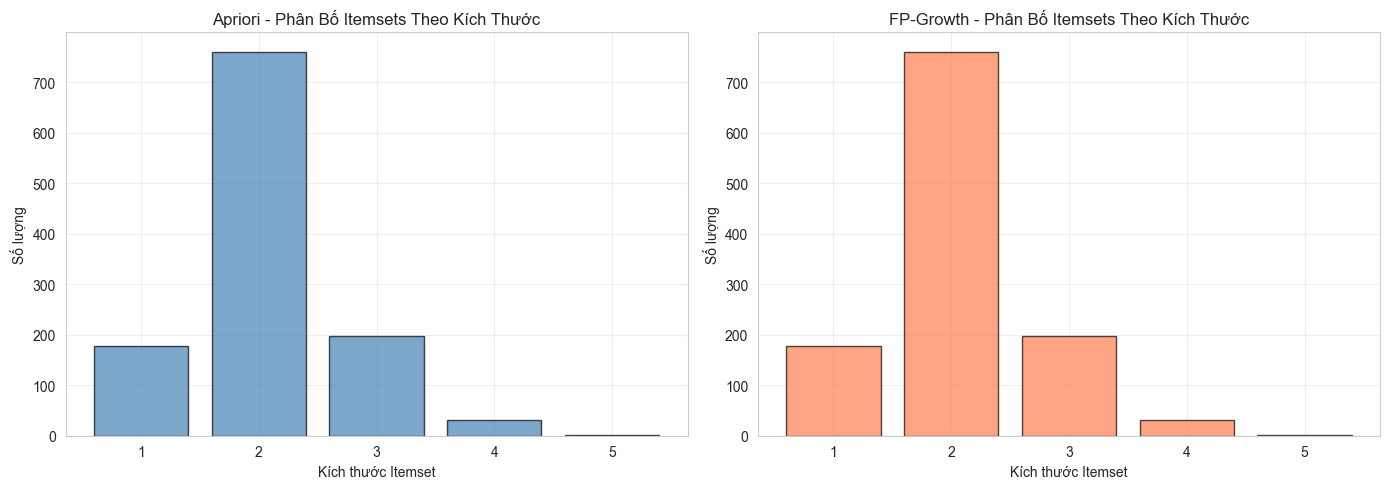

✓ Saved: itemset_comparison.png


In [24]:
# So sánh số itemsets theo kích thước
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Apriori
apriori_sizes = frequent_itemsets_apriori['size'].value_counts().sort_index()
axes[0].bar(apriori_sizes.index, apriori_sizes.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Kích thước Itemset')
axes[0].set_ylabel('Số lượng')
axes[0].set_title('Apriori - Phân Bố Itemsets Theo Kích Thước')
axes[0].grid(True, alpha=0.3)

# FP-Growth
fpg_sizes = frequent_itemsets_fpg['size'].value_counts().sort_index()
axes[1].bar(fpg_sizes.index, fpg_sizes.values, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Kích thước Itemset')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('FP-Growth - Phân Bố Itemsets Theo Kích Thước')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'itemset_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: itemset_comparison.png")

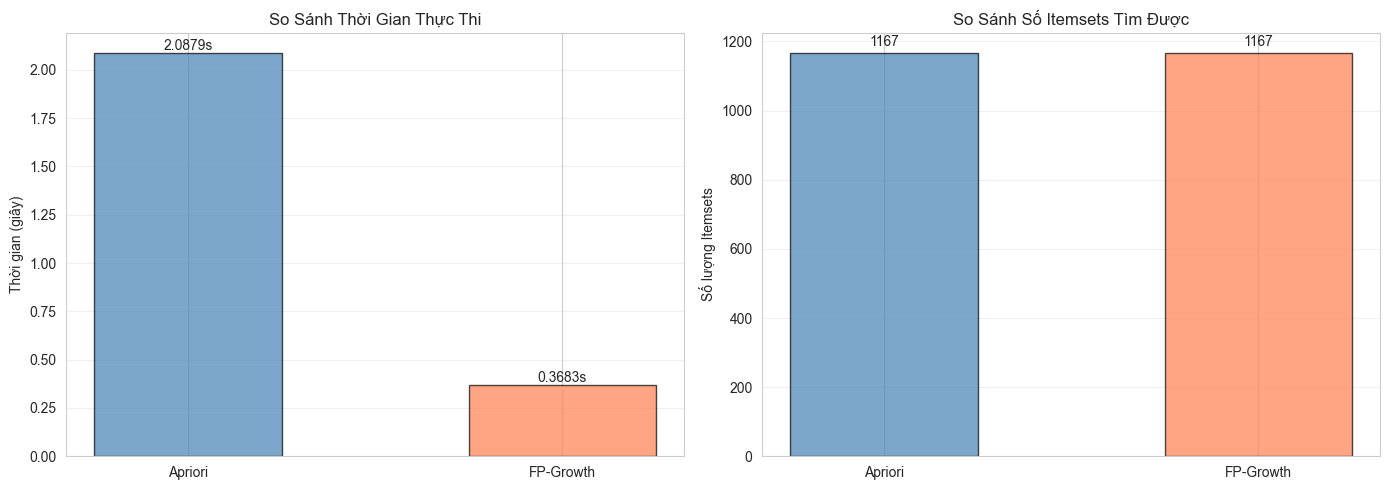

✓ Saved: performance_comparison.png


In [25]:
# So sánh hiệu năng
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Thời gian thực thi
algorithms = ['Apriori', 'FP-Growth']
times = [apriori_time, fpg_time]
colors = ['steelblue', 'coral']

axes[0].bar(algorithms, times, color=colors, alpha=0.7, edgecolor='black', width=0.5)
axes[0].set_ylabel('Thời gian (giây)')
axes[0].set_title('So Sánh Thời Gian Thực Thi')
axes[0].grid(True, alpha=0.3, axis='y')
for i, (alg, t) in enumerate(zip(algorithms, times)):
    axes[0].text(i, t + 0.001, f'{t:.4f}s', ha='center', va='bottom')

# Itemsets count
counts = [len(frequent_itemsets_apriori), len(frequent_itemsets_fpg)]
axes[1].bar(algorithms, counts, color=colors, alpha=0.7, edgecolor='black', width=0.5)
axes[1].set_ylabel('Số lượng Itemsets')
axes[1].set_title('So Sánh Số Itemsets Tìm Được')
axes[1].grid(True, alpha=0.3, axis='y')
for i, (alg, c) in enumerate(zip(algorithms, counts)):
    axes[1].text(i, c + 10, f'{c}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(output_dir / 'performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: performance_comparison.png")

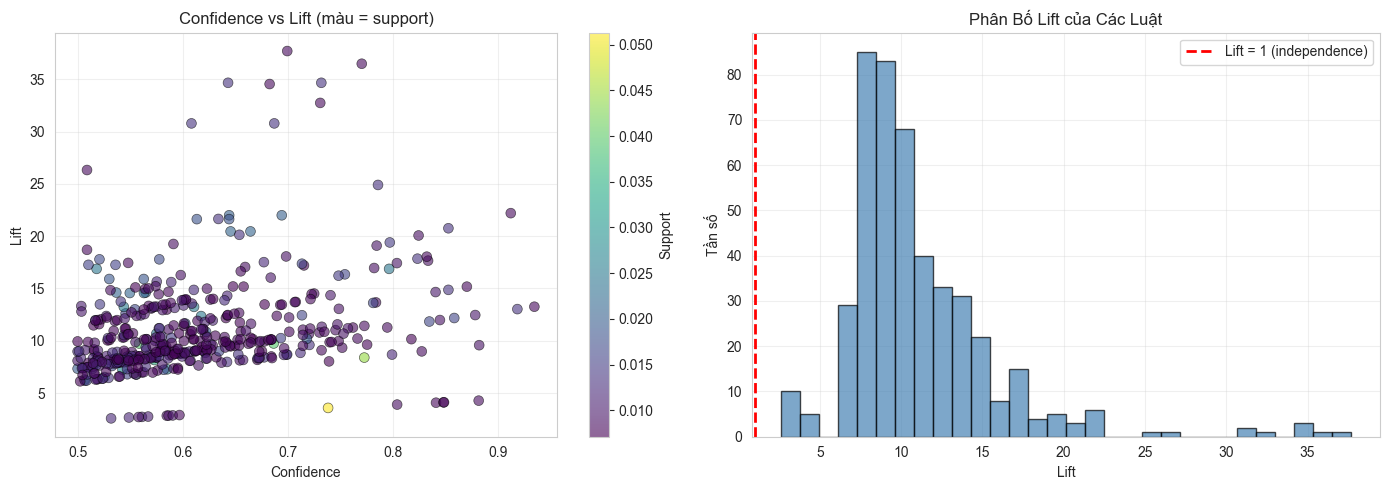

✓ Saved: rules_metrics.png


In [26]:
if len(rules_apriori) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter: Confidence vs Lift
    scatter = axes[0].scatter(rules_apriori['confidence'], rules_apriori['lift'], 
                             c=rules_apriori['support'], cmap='viridis', 
                             alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Lift')
    axes[0].set_title('Confidence vs Lift (màu = support)')
    axes[0].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[0])
    cbar.set_label('Support')
    
    # Histogram: Lift distribution
    axes[1].hist(rules_apriori['lift'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Lift = 1 (independence)')
    axes[1].set_xlabel('Lift')
    axes[1].set_ylabel('Tần số')
    axes[1].set_title('Phân Bố Lift của Các Luật')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'rules_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: rules_metrics.png")

## 9. Xuất Kết Quả

In [27]:
print(f"\n{'='*70}")
print("XUẤT KỂT QUẢ")
print(f"{'='*70}\n")

# Xuất Apriori itemsets
apriori_export = frequent_itemsets_apriori[['itemsets', 'support', 'support_count', 'size']].copy()
apriori_export['itemsets'] = apriori_export['itemsets'].apply(lambda x: '|'.join(sorted(list(x))))
apriori_export.columns = ['Itemset', 'Support', 'Support_Count', 'Size']
apriori_file = output_dir / 'apriori_itemsets.csv'
apriori_export.to_csv(apriori_file, index=False)
print(f"✓ Exported: apriori_itemsets.csv ({len(apriori_export)} rows)")

# Xuất FP-Growth itemsets
fpg_export = frequent_itemsets_fpg[['itemsets', 'support', 'support_count', 'size']].copy()
fpg_export['itemsets'] = fpg_export['itemsets'].apply(lambda x: '|'.join(sorted(list(x))))
fpg_export.columns = ['Itemset', 'Support', 'Support_Count', 'Size']
fpg_file = output_dir / 'fpgrowth_itemsets.csv'
fpg_export.to_csv(fpg_file, index=False)
print(f"✓ Exported: fpgrowth_itemsets.csv ({len(fpg_export)} rows)")

# Xuất Rules
if len(rules_apriori) > 0:
    rules_export = rules_apriori[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: '|'.join(sorted(list(x))))
    rules_export['consequents'] = rules_export['consequents'].apply(lambda x: '|'.join(sorted(list(x))))
    rules_export.columns = ['Antecedents', 'Consequents', 'Support', 'Confidence', 'Lift']
    rules_file = output_dir / 'association_rules.csv'
    rules_export.to_csv(rules_file, index=False)
    print(f"✓ Exported: association_rules.csv ({len(rules_export)} rows)")

# Xuất thống kê
stats_data = {
    'Algorithm Comparison': {
        'Apriori': {
            'itemsets': int(len(frequent_itemsets_apriori)),
            'execution_time': float(apriori_time),
            '1-itemsets': int((frequent_itemsets_apriori['size'] == 1).sum()),
            '2-itemsets': int((frequent_itemsets_apriori['size'] == 2).sum()),
            'max_itemset_size': int(frequent_itemsets_apriori['size'].max())
        },
        'FP-Growth': {
            'itemsets': int(len(frequent_itemsets_fpg)),
            'execution_time': float(fpg_time),
            '1-itemsets': int((frequent_itemsets_fpg['size'] == 1).sum()),
            '2-itemsets': int((frequent_itemsets_fpg['size'] == 2).sum()),
            'max_itemset_size': int(frequent_itemsets_fpg['size'].max())
        }
    },
    'Parameters': {
        'min_support_count': int(min_support_count),
        'min_support_relative': float(min_support_relative),
        'min_confidence': float(min_confidence),
        'n_transactions': int(n_transactions),
        'n_items': int(df_transactions.shape[1])
    },
    'Rules': {
        'total_rules': int(len(rules_apriori)) if len(rules_apriori) > 0 else 0,
        'avg_confidence': float(rules_apriori['confidence'].mean()) if len(rules_apriori) > 0 else 0,
        'avg_lift': float(rules_apriori['lift'].mean()) if len(rules_apriori) > 0 else 0
    }
}

stats_file = output_dir / 'statistics.json'
with open(stats_file, 'w') as f:
    json.dump(stats_data, f, indent=2)
print(f"✓ Exported: statistics.json")

print(f"\n✓ Output directory: {output_dir}")


XUẤT KỂT QUẢ

✓ Exported: apriori_itemsets.csv (1167 rows)
✓ Exported: fpgrowth_itemsets.csv (1167 rows)
✓ Exported: association_rules.csv (457 rows)
✓ Exported: statistics.json

✓ Output directory: /Users/nangvuong/Desktop/association-rule-project/outputs/library
